In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/Users/dhanukarishika/Desktop/FoodWasteRiskEngine/data/raw/Dataset.csv")

In [3]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10995 entries, 0 to 10994
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Fruit        10995 non-null  object 
 1   Temp         10995 non-null  int64  
 2   Humid (%)    10995 non-null  int64  
 3   Light (Fux)  10995 non-null  float64
 4   CO2 (pmm)    10995 non-null  int64  
 5   Class        10995 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 515.5+ KB


In [4]:
df.columns = ["Fruit","Temp","Humidity","Light","CO2","Class"]

df.head()

,Fruit,Temp,Humidity,Light,CO2,Class
0,Orange,22,95,7.358649,361,Good
1,Orange,24,95,14.835898,370,Bad
2,Pineapple,25,95,10.104045,355,Bad
3,Banana,25,89,20.179643,388,Good
4,Tomato,23,90,12.621448,316,Good


In [5]:
df["Class"] = df["Class"].str.lower()

df["Class"].value_counts()

Class
good    5667
bad     5328
Name: count, dtype: int64

In [6]:
df["Class"] = df["Class"].map({"good":0,"bad":1})

df["Class"].value_counts()

Class
0    5667
1    5328
Name: count, dtype: int64

In [7]:
df = pd.get_dummies(df, columns=["Fruit"], drop_first=True)

df.head()

,Temp,Humidity,Light,CO2,Class,Fruit_Orange,Fruit_Pineapple,Fruit_Tomato
0,22,95,7.358649,361,0,True,False,False
1,24,95,14.835898,370,1,True,False,False
2,25,95,10.104045,355,1,False,True,False
3,25,89,20.179643,388,0,False,False,False
4,23,90,12.621448,316,0,False,False,True


In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9045020463847203


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9986357435197817


In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9972714870395635


In [13]:
train_pred = gb.predict(X_train)
test_pred = gb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9971577989995453
Test Accuracy: 0.9972714870395635


In [14]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, gb_pred)

array([[1125,    5],
       [   1, 1068]])

In [15]:
df["Class"].value_counts()

Class
0    5667
1    5328
Name: count, dtype: int64

In [16]:
importance = gb.feature_importances_

import pandas as pd

pd.DataFrame({
"Feature": X.columns,
"Importance": importance
}).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,Light,0.396278
1,Humidity,0.354726
0,Temp,0.158553
5,Fruit_Pineapple,0.060252
3,CO2,0.019811
6,Fruit_Tomato,0.006506
4,Fruit_Orange,0.003874


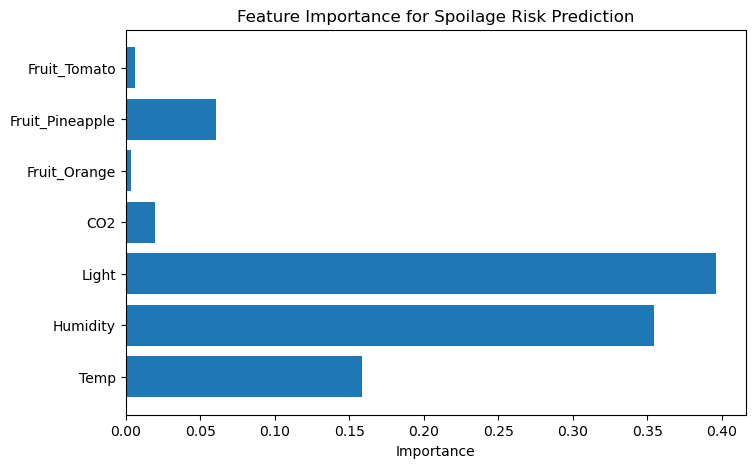

In [17]:
import matplotlib.pyplot as plt

importances = gb.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importances)

plt.title("Feature Importance for Spoilage Risk Prediction")

plt.xlabel("Importance")

plt.show()

In [18]:
!pip install shap

In [19]:
import shap
shap.initjs()

In [20]:
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

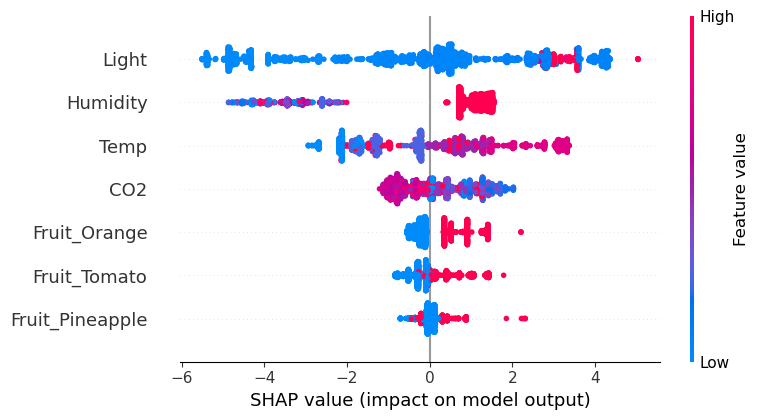

In [21]:
shap.summary_plot(shap_values, X_test)

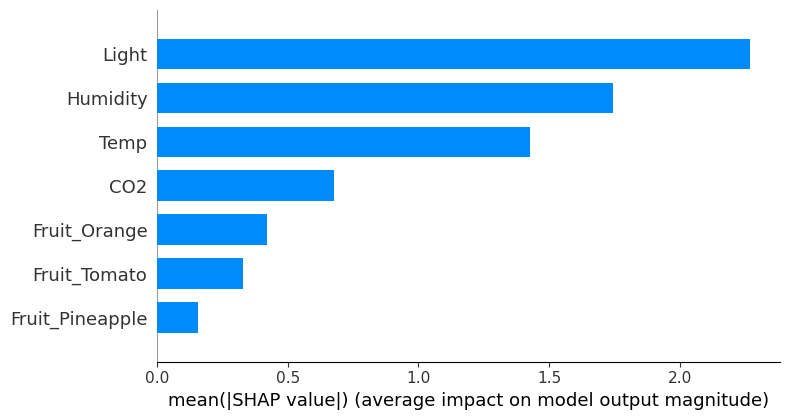

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

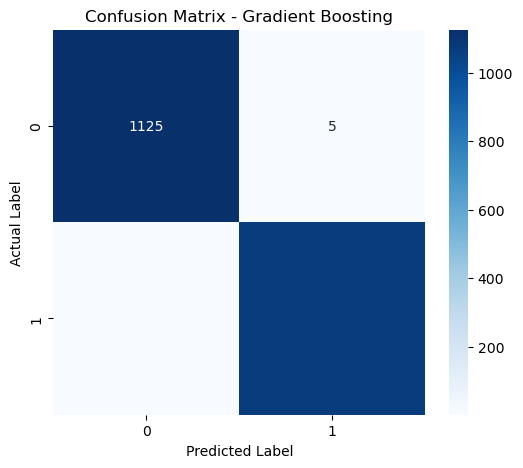

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

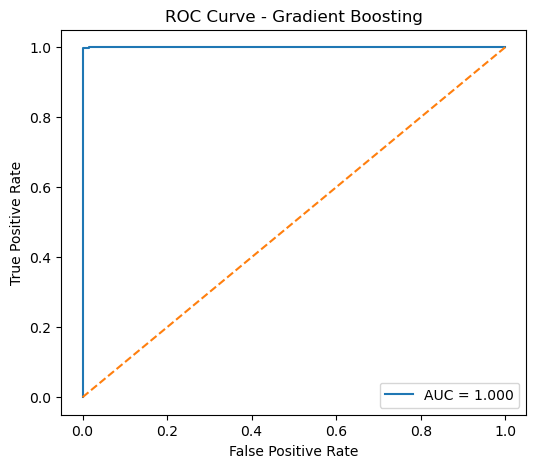

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# probability predictions
y_prob = gb.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve - Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [25]:
prob = gb.predict_proba(X_test)

risk_score = prob[:,1] * 100

In [26]:
def risk_zone(score):

    if score < 30:
        return "Low"

    elif score < 60:
        return "Moderate"

    elif score < 80:
        return "High"

    else:
        return "Critical"

zones = [risk_zone(x) for x in risk_score]


In [27]:
risk_df = pd.DataFrame({
    "Risk Score": risk_score,
    "Risk Zone": zones
})

In [28]:
zone_counts = risk_df["Risk Zone"].value_counts()

print(zone_counts)

Risk Zone
Low         1116
Critical    1067
Moderate      12
High           4
Name: count, dtype: int64


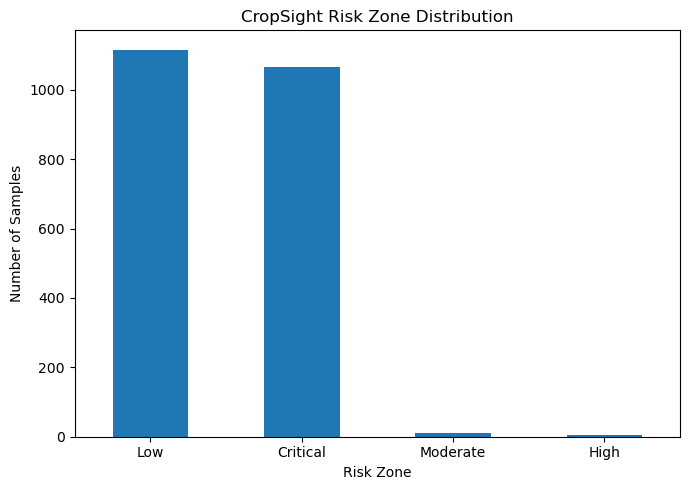

In [29]:
plt.figure(figsize=(7,5))

zone_counts.plot(kind="bar")

plt.title("CropSight Risk Zone Distribution")

plt.xlabel("Risk Zone")

plt.ylabel("Number of Samples")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [31]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [32]:
results = pd.DataFrame({

"Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],

"Accuracy": [
accuracy_score(y_test, y_pred_lr),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_gb)
],

"Precision": [
precision_score(y_test, y_pred_lr, pos_label=1),
precision_score(y_test, y_pred_rf, pos_label=1),
precision_score(y_test, y_pred_gb, pos_label=1)
],

"Recall": [
recall_score(y_test, y_pred_lr, pos_label=1),
recall_score(y_test, y_pred_rf, pos_label=1),
recall_score(y_test, y_pred_gb, pos_label=1)
],

"F1 Score": [
f1_score(y_test, y_pred_lr, pos_label=1),
f1_score(y_test, y_pred_rf, pos_label=1),
f1_score(y_test, y_pred_gb, pos_label=1)
]

})

In [33]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.904502,0.875109,0.937325,0.905149
1,Random Forest,0.998636,0.998131,0.999065,0.998597
2,Gradient Boosting,0.997271,0.995340,0.999065,0.997199


In [34]:
results.iloc[:,1:] = results.iloc[:,1:] * 100
results.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,90.45,87.51,93.73,90.51
1,Random Forest,99.86,99.81,99.91,99.86
2,Gradient Boosting,99.73,99.53,99.91,99.72


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

rf = RandomForestClassifier()
gb = GradientBoostingClassifier()

rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
gb_scores = cross_val_score(gb, X, y, cv=5, scoring='accuracy')

print("Random Forest CV Accuracy:", rf_scores)
print("Random Forest Mean Accuracy:", rf_scores.mean())

print("Gradient Boosting CV Accuracy:", gb_scores)
print("Gradient Boosting Mean Accuracy:", gb_scores.mean())

Random Forest CV Accuracy: [0.99863574 0.9990905  1.         0.99863574 0.85902683]
Random Forest Mean Accuracy: 0.9710777626193725
Gradient Boosting CV Accuracy: [0.99454297 0.99636198 0.99681673 0.99363347 0.66166439]
Gradient Boosting Mean Accuracy: 0.9286039108685766
